# Parcial 3

Metas:

- Documentacion de las bases de datos IIIII
- Pregunta 1 - Lectura, Limpieza y transformacion de datos 11 AM IIIII IIIII IIIII III
- Pregunta 2 - FACIL IIIII III
- Pregunta 3 - MEDIO - 12PM
- Pregunta 4 - MEDIO 
- Pregunta 5 - FACIL - 2PM
- Pregunta 6 - DIFICIL
- Pregunta 7 - DIFICIL - 4PM
- Pregunta 8 - MEDIO -5PM

## PENDIENTES

- Que significan los valores de la actividad industrial? La respuesta debe estar [aqui](https://www.inegi.org.mx/contenidos/productos/prod_serv/contenidos/espanol/bvinegi/productos/nueva_estruc/889463913825.pdf#page=158).

## Comprendiendo las bases de datos

---

Todas las bases de datos fueron extraidas del INEGI. A continuacion se listan los archivos relevantes y se agrega una breve descripcion del tipo de informacion que contienen:

- **Educacion.csv**: Matricula escolar por entidad federativa según nivel educativo. Los ciclos escolares seleccionados son del 2020/2021 al 2022/2023.
- **Actividad_Inturstrial.csv**: Indicador Mensual de la Actividad Industrial por Entidad Federativa. El año base es 2018. Datos del 2003 al 2025. Contiene varios estadisticos relacionados a la actividad industrial por entidad federativa, siendo uno de ellos el Índice de volumen físico base 2018=100.
- **PIB.csv**: Producto Interno Bruto por Entidad Federativa. Año base 2013. Contiene varios estadisticos relacionados al PIB por entidad federativa, siendo uno de ellos el PIB en valores constantes. Datos del 2003 al 2021.

> Notese que los archivos `Actividad_Industrial` y `Educacion` estaban en formato .xlsx. Se guardaron como csv para facilitar la lectura de datos.

La base de datos *PIB.csv* tiene mas informacion de la necesaria, pues solo se necestia el valor del PIB en valores constantes para resolver las preguntas planteadas. Habra que limpiar adecuadamente dicha base de datos. Por otro lado, la base de datos *Actividad_Industrial.xlsx* tiene un periodo mensual, el cual se tendra que transformar a un periodo anual.

### Base de datos faltante y cifras desactualizadas

Las preguntas 2 y 3 hacen referencia a una tabla de desocupacion. En las bases de datos listadas no hay ninguna que incluya informacion respecto a la tasa de desocupacion por entidad, por lo tanto se asume que omitio por error el agregarla. Esto por esto que se añade el archivo **Ocupacion.csv**, el cual contiene las tasas de ocupacion mensual por entidad federativa en el periodo 2005 a 2026. Usando este archivo se calculara la tasa de desocupacion mensual por entidad federativa.

La base de datos se obtuvo del [Banco de Información Económica (BIE)](https://www.inegi.org.mx/app/indicadores/default.aspx?tm=3#D697711_3900) del INEGI.

## Pregunta 1

> "Carga los tres CSV, revisa nombres de columnas, tipos de dato, caracteres especiales, claves de entidad y formatos de fecha. Homologa los nombres de las entidades entre tablas, genera una columna de year en todas y una columna year_month en las tablas mensuales. Después convierte las dos tablas mensuales a frecuencia anual mediante promedio anual, une las tres tablas en una sola base final a nivel entidad-year (12.5 pts)." 

Tareas:

- Limpieza de datos
    - FALTA: Formatos de fecha
- 



Primero importamos las librerias necesarias:


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

Ahora realizamos la lectura de las cuatro bases de datos:

In [2]:
df_pib = pd.read_csv("../INPUTS/PIB.csv")
df_edu = pd.read_csv("../INPUTS/Educacion.csv")
df_indus = pd.read_csv("../INPUTS/Actividad_Intustrial.csv")
df_des = pd.read_csv("../INPUTS/Desocupacion.csv", encoding="latin-1")


### Helper functions

#### Funciones de limpieza de datos


In [3]:
def clean_list_mapping(original_list: list, cleaned_list: list) -> dict:
    """Retorna un diccionario con los valores originales de una lista y sus valores 'limpios'."""
    mapping = {}
    for i, entry in enumerate(original_list):
        mapping[entry] = cleaned_list[i]
    return mapping

def clean_list_strings(list_to_clean: list) -> list:
    """Retorna una lista con los valores 'limpios'. Mantiene invariantes los distintos tipos de missing values. Remueve leading y trailing whitespaces; pone todo en mayus; remplaza
    whitespaces por underscores; remplaza multiples underscores contiguos por uno solo; y remueve cualquier caracter que no sea una letra mayus, un guion bajo o un digito. Enfocado
    en listas con strings."""
    cleaned_list = []
    for i, is_nan in enumerate(pd.isna(list_to_clean)):
        if is_nan:
            cleaned_list.append(list_to_clean[i])
        else:
            cleaned_list.append(re.sub(r"[^A-Z_\d]", "", re.sub(r"_+", "_", str(list_to_clean[i]).strip().upper().replace(" ", "_"))))
    return cleaned_list

def clean_list_strings_no_digits(list_to_clean: list) -> list:
    """Retorna una lista con los valores limpios. Similar a clean_list_strings, pero tambien remueve digitos."""
    cleaned_list = []
    for i, is_nan in enumerate(pd.isna(list_to_clean)):
        if is_nan:
            cleaned_list.append(list_to_clean[i])
        else:
            cleaned_list.append(re.sub(r"[^A-Z_]", "", re.sub(r"_+", "_", str(list_to_clean[i]).strip().upper().replace(" ", "_"))).strip("_"))
    return cleaned_list

def clean_list_integers(list_to_clean: list) -> list:
    """Retorna una lista con los valores limpios. Elimina todo menos los digitos. Mantiene invariantes los distintos tipos de missing values."""
    cleaned_list = []
    for i, is_nan in enumerate(pd.isna(list_to_clean)):
        if is_nan:
            cleaned_list.append(list_to_clean[i])
        else:
            cleaned_list.append(re.sub(r"[^\d]", "", str(list_to_clean[i])))
    return cleaned_list

def fill_integer_list(list_to_fill: list) -> list:
    """Retorna una lista donde se sutituyen las entradas nan o "" con el entero inmediato anterior."""
    current_value = ""
    filled_list = []
    for i, is_nan in enumerate(pd.isna(list_to_fill)):
        if (is_nan) | (str(list_to_fill[i]).strip() == ""):
            filled_list.append(current_value)
        else:
            current_value = int(str(list_to_fill[i]).strip())
            filled_list.append(current_value)
    return  filled_list

def fill_float_list(list_to_fill: list) -> list:
    """Retorna una lista donde se sustituyen las entradas nan o "" con el valor flotante inmediato anterior."""
    current_value = 0.0
    filled_list = []
    for i, is_nan in enumerate(pd.isna(list_to_fill)):
        if (is_nan) | (str(list_to_fill[i]).strip() == "") | ((str(list_to_fill[i]).strip() == "ND")):  # Una tabla usa NA cuando no hay datos
            filled_list.append(current_value)
        else:
            current_value = float(str(list_to_fill[i]).strip())
            filled_list.append(current_value)
    return filled_list

def clean_state_names(list_states: list) -> list:
    """Retorna una lista con los acentos removidos"""
    new_list_states =[]
    for state in list_states:
        if pd.isna([state]):
            new_list_states.append(state)
        else:
            new_list_states.append(state.replace("á", "a").replace("é", "e").replace("í", "i").replace("ó", "o").replace("ú", "u").replace("Á", "A").replace("É", "E").replace("Í", "I").replace("Ó", "O").replace("Ú", "U"))
    return new_list_states

#test_list = [10, np.nan, 10, np.nan, np.nan, np.nan, "   1    ", "abd 9 p", "", "1"]
#display(fill_integer_list(test_list))
#display(bool(" "))

#test_list = [2020, "2021_P", "2022_C"]

### Limpieza transformacion de datos

#### `df_pib`

Empezaremos limpiando el dataframe `df_pib`. Como solo nos interesan el PIB en *valores constantes*, hay que remover las filas que no esten asociadas a este. Como se vio en la impresion anterior, la primer entidad federativa que aparece es 'Aguascalientes', asociada al indice 6. De esta manera, para limpiar la base eliminaremos todas las filas menos las asociadas al indice 6 y los 31 posteriores (dado que hay 32 entidades federativas).


In [4]:
display(df_pib.head(10))

,Concepto,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020 R,2021 P
0,Valores constantes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Millones de pesos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a B.1bP - Producto interno bruto,1.306172e+07,1.357382e+07,1.388707e+07,1.451131e+07,1.484383e+07,1.501358e+07,1.422000e+07,1.494779e+07,1.549533e+07,1.605972e+07,1.627719e+07,1.674105e+07,1.729236e+07,1.774724e+07,1.812226e+07,1.852004e+07,1.848318e+07,1.700676e+07,1.780958e+07
3,"D.21-D.31 - Impuestos sobre los productos, netos",5.026134e+05,5.231279e+05,5.393506e+05,5.799235e+05,5.893617e+05,6.108211e+05,5.714514e+05,5.953940e+05,6.195370e+05,6.287311e+05,6.345672e+05,6.738922e+05,7.129446e+05,7.646889e+05,7.924520e+05,8.187794e+05,8.171210e+05,7.102331e+05,7.688815e+05
4,a B.1bV - Valor agregado bruto,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Estados Unidos Mexicanos,1.255911e+07,1.305069e+07,1.334772e+07,1.393138e+07,1.425446e+07,1.440276e+07,1.364855e+07,1.435240e+07,1.487580e+07,1.543099e+07,1.564262e+07,1.606716e+07,1.657941e+07,1.698255e+07,1.732981e+07,1.770126e+07,1.766606e+07,1.629653e+07,1.704069e+07
6,Aguascalientes,1.211976e+05,1.265541e+05,1.296280e+05,1.381118e+05,1.503051e+05,1.509500e+05,1.432539e+05,1.522052e+05,1.589345e+05,1.677060e+05,1.728205e+05,1.904829e+05,1.982206e+05,2.116725e+05,2.167056e+05,2.248916e+05,2.224513e+05,2.048204e+05,2.067149e+05
7,Baja California,3.995146e+05,4.230055e+05,4.330082e+05,4.560193e+05,4.615813e+05,4.575566e+05,4.077459e+05,4.281625e+05,4.407007e+05,4.560245e+05,4.655247e+05,4.781219e+05,5.114595e+05,5.355527e+05,5.533272e+05,5.660459e+05,5.753325e+05,5.540080e+05,5.992210e+05
8,Baja California Sur,7.604759e+04,8.154601e+04,8.739767e+04,9.365562e+04,1.061994e+05,1.089754e+05,1.083388e+05,1.106564e+05,1.147078e+05,1.173458e+05,1.150276e+05,1.160270e+05,1.305206e+05,1.339487e+05,1.483766e+05,1.732006e+05,1.589537e+05,1.219020e+05,1.411761e+05
9,Campeche,1.047511e+06,1.059561e+06,1.038534e+06,1.014280e+06,9.475755e+05,8.672310e+05,7.807574e+05,7.539686e+05,7.265039e+05,7.147871e+05,7.210851e+05,6.859813e+05,6.376046e+05,6.006123e+05,5.378826e+05,5.294657e+05,5.173093e+05,4.819699e+05,4.623526e+05


In [5]:
df_pib_cleaned_v01 = df_pib.copy() 

df_pib_cleaned_v01 = df_pib.iloc[6:(6+32)]    # Nos quedamos con las filas relevantes
df_pib_cleaned_v01 = df_pib_cleaned_v01.rename(columns=clean_list_mapping(df_pib_cleaned_v01.columns, clean_list_integers(df_pib_cleaned_v01.columns)))    # Limpiamos y reasignamos los nombres de las columnas usando las funciones de limpieza previamente definidas
df_pib_cleaned_v01 = df_pib_cleaned_v01.rename(columns={"":"ENTIDAD"})    # Cambiamos el nombre de la primera columna
#df_pib_cleaned_v01 = df_pib_cleaned_v01.rename(columns={"2020_R":"2020", "2021_P":"2021"})    # Ajustamos los nombres de columna de los ultimos dos años
df_pib_cleaned_v01 = df_pib_cleaned_v01.reset_index(drop=True)    # Reiniciamos el indice y eliminamos el anterior

# Estandarizamos los nombres de las entidades usando las funciones clean_list_strings y clean_state_names
entidades = df_pib_cleaned_v01.loc[:,"ENTIDAD"]
entidades_standard = clean_list_strings(clean_state_names(entidades))

# Cambiamos los valores de las entidades en el dataframe por los valores estandarizados
df_pib_cleaned_v01.loc[:, "ENTIDAD"] = entidades_standard

display(df_pib_cleaned_v01)


,ENTIDAD,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,AGUASCALIENTES,121197.634,126554.147,129628.028,138111.823,150305.117,150949.983,143253.947,152205.212,158934.494,167705.967,172820.491,190482.862,198220.641,211672.469,216705.560,224891.592,222451.271,204820.383,206714.882
1,BAJA_CALIFORNIA,399514.624,423005.499,433008.166,456019.296,461581.274,457556.565,407745.948,428162.546,440700.662,456024.472,465524.695,478121.939,511459.528,535552.651,553327.213,566045.913,575332.463,554008.043,599221.032
2,BAJA_CALIFORNIA_SUR,76047.593,81546.009,87397.670,93655.622,106199.426,108975.356,108338.811,110656.400,114707.762,117345.833,115027.644,116027.018,130520.642,133948.675,148376.630,173200.594,158953.669,121901.971,141176.059
3,CAMPECHE,1047511.322,1059561.025,1038533.775,1014280.350,947575.493,867231.044,780757.429,753968.591,726503.856,714787.065,721085.063,685981.270,637604.643,600612.272,537882.577,529465.695,517309.327,481969.908,462352.560
4,COAHUILA_DE_ZARAGOZA,436573.518,449143.882,458867.907,480488.194,500478.657,498326.775,421327.489,489951.776,523207.112,549551.802,538206.987,559217.153,563928.440,572243.615,601722.052,608138.802,603865.640,535908.391,567404.536
5,COLIMA,67732.930,67794.051,68258.171,72533.785,77526.370,78953.717,76446.900,81992.178,87944.969,90540.289,91422.446,93703.258,95878.066,98576.211,102039.429,105031.030,109098.972,101198.825,101360.669
6,CHIAPAS,248123.227,238375.890,240279.559,248414.302,252536.304,258289.890,256698.362,270989.331,279446.584,284733.625,280925.273,294029.165,287811.831,287034.269,277580.835,267664.128,261684.516,254446.976,268174.259
7,CHIHUAHUA,360426.663,376662.637,389210.794,419631.539,434649.920,440792.887,401079.179,417796.420,427430.027,459166.220,476290.197,485693.517,510642.914,534205.546,551497.303,564077.669,572880.305,539798.460,566202.558
8,CIUDAD_DE_MEXICO,2132929.372,2226949.736,2258091.583,2374722.886,2408565.865,2450391.202,2362516.439,2446910.439,2533806.893,2633934.642,2673066.331,2748551.988,2869792.908,2957233.594,3045539.859,3126459.566,3132839.076,2856971.791,2944607.206
9,DURANGO,152922.727,157662.281,155001.886,160388.081,162709.802,165722.989,163083.647,169268.084,176314.713,182943.056,189052.812,192968.629,192888.101,200660.962,199559.310,202272.029,204045.941,189953.176,200396.979


##### Transformacion - dataframe final

In [6]:
df_pib_cleaned_v02 = df_pib_cleaned_v01.copy()

# Usamos el metodo .melt para deformar el dataframe, agregando en el proceso la columna "YEAR"
df_pib_cleaned_v02 = df_pib_cleaned_v02.melt(id_vars="ENTIDAD", var_name="YEAR", value_name="PIB_(PRECIOS_CORRIENTES)")

# Ajustamos el tipo de dato de la columna "YEAR"
df_pib_cleaned_v02["YEAR"] = df_pib_cleaned_v02["YEAR"].astype(int)

display(df_pib_cleaned_v02)

,ENTIDAD,YEAR,PIB_(PRECIOS_CORRIENTES)
0,AGUASCALIENTES,2003,121197.634
1,BAJA_CALIFORNIA,2003,399514.624
2,BAJA_CALIFORNIA_SUR,2003,76047.593
3,CAMPECHE,2003,1047511.322
4,COAHUILA_DE_ZARAGOZA,2003,436573.518
...,...,...,...
603,TAMAULIPAS,2021,481559.431
604,TLAXCALA,2021,94889.135
605,VERACRUZ_DE_IGNACIO_DE_LA_LLAVE,2021,767013.242
606,YUCATAN,2021,259829.011


#### `df_indus`

Ahora limpiamos el dataframe `df_indus` asociado a la actividad industrial. Primero vemos las primeras 10 entradas del dataframe.

In [7]:
display(df_indus.head(10))


,Instituto Nacional de Estadística y Geografía (INEGI).,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 290,Unnamed: 291,Unnamed: 292,Unnamed: 293,Unnamed: 294,Unnamed: 295,Unnamed: 296,Unnamed: 297,Unnamed: 298,Unnamed: 299
0,Sistema de Cuentas Nacionales de México. Indic...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Actividades económicas por entidad federativa/...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Concepto,2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,...,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre,Anual
5,Índice de volumen físico base 2018=100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Estados Unidos Mexicanos,80.9,80.5,83.0,81.7,82.0,81.7,83.6,83.8,85.2,...,100.2,104.5,100.9,101.7,101.5,99.6,104.9,101.6,98.4,101.0
7,Aguascalientes,42.0,40.9,39.3,41.9,40.4,41.5,45.6,47.1,44.8,...,95.5,100.4,94.9,91.7,100.2,95.7,98.7,89.6,78.1,93.9
8,Baja California,86.3,83.3,79.5,84.9,79.7,84.6,87.9,86.7,87.4,...,111.1,113.4,111.9,107.9,107.1,109.7,113.6,107.0,96.6,108.8
9,Baja California Sur,44.9,48.3,53.1,52.8,43.6,48.1,45.0,45.8,63.6,...,69.5,73.4,72.2,76.6,80.2,71.2,69.4,72.7,66.0,70.7


Como solo interesa la informacion pertinente al Indice de volumen fisico, solo nos enteresan las 32 filas de las entidades federativas que inician en el indice 7, y las filas asociadas a los incides 3 y 4 (las cuales contienen la informacion del año y el mes, respectivamente).

In [8]:
df_indus_cleaned_v01 = df_indus.copy()
df_indus_cleaned_v01 = df_indus_cleaned_v01.iloc[[3,4]+[i+7 for i in range(32)]]    # Solo filas de entidades, de ano y de mes.
df_indus_cleaned_v01 = df_indus_cleaned_v01.reset_index(drop=True)    # Reiniciamos el index

# Fila "YEAR": Cambiamos "concepto" a "YEAR", y rellenamos los valores NaN 
row_year = df_indus_cleaned_v01.iloc[0]
row_year = clean_list_integers(row_year)
row_year = fill_integer_list(row_year)
row_year[0] = "YEAR"
df_indus_cleaned_v01.iloc[0] = row_year

# Fila "YEAR_MONTH": Cambiamos la 2da fila al formato YYYY_MM
month_to_int = {"enero":1,
                "febrero":2,
                "marzo":3,
                "abril":4,
                "mayo":5,
                "junio":6,
                "julio":7,
                "agosto":8,
                "septiembre":9,
                "octubre":10,
                "noviembre":11,
                "diciembre":12}

row_month = df_indus_cleaned_v01.iloc[1]
row_month = clean_list_strings(row_month)

new_row_month = []
for i, entry in enumerate(row_month):
    if pd.isnull(entry):
        new_row_month.append("YEAR_MONTH")
    else:
        if entry == "ANUAL":
            new_row_month.append(str(row_year[i])+"_"+entry)
        else:
            new_row_month.append(str(row_year[i])+"_"+str(month_to_int[entry.lower()]))

df_indus_cleaned_v01.iloc[1] = new_row_month

# Definimos las filas YEAR y YEAR_MONTH como un multindex y lo asignamos al column index del dataframe; eliminamos las primeras dos filas (se vuelven redundantes pues son el column index).
new_columns_index = pd.MultiIndex.from_arrays([[""]+df_indus_cleaned_v01.iloc[0][1:].tolist(), ["ENTIDAD"]+df_indus_cleaned_v01.iloc[1][1:].tolist()], names=("", ""))
df_indus_cleaned_v01.columns = new_columns_index
df_indus_cleaned_v01 = df_indus_cleaned_v01.iloc[2:].reset_index(drop=True)

# Usamos la function clean_list_string y clean_state_names para limpiar los nombres de las entidades.
entidades = df_indus_cleaned_v01[""]["ENTIDAD"].values
entidades = clean_list_strings(clean_state_names(entidades))

# Evaluamos si las entidades son iguales al standard definido previamente; si es asi, reasignamos los valores de la columna "ENTIDAD" a las entidades estandarizadas
if entidades == entidades_standard:
    df_indus_cleaned_v01.loc[:,[("", "ENTIDAD")]] = entidades_standard
else:
    print("NO HAY PARIDAD EN LOS NOMBRES DE LAS ENTIDADES")

display(df_indus_cleaned_v01)

C:\Users\ossia\AppData\Local\Temp\ipykernel_12068\2380217395.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cleaned_list.append(re.sub(r"[^\d]", "", str(list_to_clean[i])))
C:\Users\ossia\AppData\Local\Temp\ipykernel_12068\2380217395.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cleaned_list.append(list_to_clean[i])
C:\Users\ossia\AppData\Local\Temp\ipykernel_12068\2380217395.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc

2003                                     \
                            ENTIDAD 2003_1 2003_2 2003_3 2003_4 2003_5 2003_6   
0                    AGUASCALIENTES   42.0   40.9   39.3   41.9   40.4   41.5   
1                   BAJA_CALIFORNIA   86.3   83.3   79.5   84.9   79.7   84.6   
2               BAJA_CALIFORNIA_SUR   44.9   48.3   53.1   52.8   43.6   48.1   
3                          CAMPECHE  197.7  179.6  200.0  190.6  197.6  197.2   
4              COAHUILA_DE_ZARAGOZA   74.2   77.6   81.5   76.7   78.5   74.3   
5                            COLIMA   54.8   62.2   79.0   81.4   70.4   71.6   
6                           CHIAPAS  165.3  143.4  150.5  134.4  127.4  125.2   
7                         CHIHUAHUA   63.5   63.3   67.1   60.3   58.2   59.0   
8                  CIUDAD_DE_MEXICO  119.7  122.3  124.3  123.3  125.2  119.7   
9                           DURANGO   63.1   68.0   69.8   65.6   65.9   69.3   
10                       GUANAJUATO   59.2   59.6   59.8   58.0   59.2   60.6   
11                         GUERRERO   58.3   59.0   63.9   68.7   63.6   62.9   
12                          HIDALGO   93.3   94.0   98.2  101.2  101.7   96.9   
13                          JALISCO   71.2   72.8   69.8   71.5   72.6   71.4   
14                           MEXICO   73.1   74.7   76.4   77.7   80.5   80.7   
15              MICHOACAN_DE_OCAMPO   83.7   82.6   86.7   84.4   82.2   82.3   
16                          MORELOS   78.4   79.7   81.8   76.5   82.1   82.3   
17                          NAYARIT   71.7   71.3   69.4   73.0   70.7   69.7   
18                       NUEVO_LEON   70.2   73.0   70.4   73.0   70.5   70.9   
19                           OAXACA  119.1  115.5  121.4  123.7  122.5  120.7   
20                           PUEBLA   57.1   59.5   55.4   56.8   62.5   65.8   
21                        QUERETARO   65.2   64.8   61.4   65.0   59.5   59.3   
22                     QUINTANA_ROO   60.2   58.3   62.4   59.2   62.8   66.3   
23                  SAN_LUIS_POTOSI   45.4   43.7   43.4   43.5   43.4   43.5   
24                          SINALOA   71.1   71.4   70.4   64.9   64.0   64.6   
25                           SONORA   53.0   55.2   61.2   62.6   63.4   59.3   
26                          TABASCO   88.5   82.5   91.9   85.6   89.4   90.4   
27                       TAMAULIPAS   88.3   85.0   90.8   84.2   84.7   83.0   
28                         TLAXCALA   65.1   68.8   68.8   67.6   64.9   69.6   
29  VERACRUZ_DE_IGNACIO_DE_LA_LLAVE   93.4   97.5  104.2   96.8   94.4   95.0   
30                          YUCATAN   51.9   57.2   58.1   60.5   58.4   57.0   
31                        ZACATECAS   36.7   38.6   40.3   40.8   42.2   41.3   

                         ...   2025                                     \
   2003_7 2003_8 2003_9  ... 2025_4 2025_5 2025_6 2025_7 2025_8 2025_9   
0    45.6   47.1   44.8  ...   95.5  100.4   94.9   91.7  100.2   95.7   
1    87.9   86.7   87.4  ...  111.1  113.4  111.9  107.9  107.1  109.7   
2    45.0   45.8   63.6  ...   69.5   73.4   72.2   76.6   80.2   71.2   
3   205.5  203.4  197.1  ...   69.2   70.1   63.6   63.8   62.7   59.9   
4    74.3   78.8   80.8  ...   84.8   89.0   90.3   90.2   86.2   81.5   
5    75.7   85.7   88.6  ...   95.1   90.6   82.6   82.5   81.0   74.5   
6   128.8  127.4  119.3  ...  117.0  138.2  108.5  105.2  101.5   94.0   
7    59.7   60.8   65.1  ...  109.4  112.6  112.9  111.3  111.5  112.0   
8   122.3  124.6  128.7  ...  104.2  108.3  102.3  110.7  106.2  103.1   
9    71.6   73.5   74.8  ...  104.7  108.1   98.6   97.3   98.4   89.2   
10   61.9   63.2   61.7  ...  107.2  107.2  101.9  103.6  101.5  107.8   
11   68.1   69.4   77.8  ...   70.9   82.6   73.2   83.0   81.8   80.4   
12  102.4  100.2   86.9  ...  108.7  114.0  109.9  118.5  118.9  120.5   
13   76.4   76.4   71.3  ...  105.7  111.5  107.4  107.3  105.9  107.8   
14   80.5   78.8   82.2  ...   87.2   92.7   91.5   95.9   92.2   87.1   
15   78.1   81.7   93.0  

##### Transformacion - dataframe con meses

In [9]:
df_indus_cleaned_v02 = df_indus_cleaned_v01.copy()

# Obtenemos las tuplas con los nombres de las columnas que no tienen el formato "YYYY_ANUAL"
columns_to_keep = []
for tuple in df_indus_cleaned_v02.columns:
    if ("ANUAL" not in str(tuple[0])) & ("ANUAL" not in str(tuple[1])):
        columns_to_keep.append(tuple)
    
# Filtramos, quedandonos con solo las columnas que no tiene el formato "YYYY_ANUAL"
df_indus_cleaned_v02 = df_indus_cleaned_v02.loc[:, columns_to_keep]

# Usamos el metodo .melt para deformar el dataframe, agregando en el proceso la columna "YEAR"
df_indus_cleaned_v02 = df_indus_cleaned_v02.melt(id_vars=[("", "ENTIDAD")], value_name="INDICE")
df_indus_cleaned_v02.columns = ["ENTIDAD", "YEAR", "YEAR_MONTH", "INDICE"]

# Ajustamos el tipo de dato de la columna "YEAR"
df_indus_cleaned_v02["YEAR"] = df_indus_cleaned_v02["YEAR"].astype(int)

display(df_indus_cleaned_v02)

,ENTIDAD,YEAR,YEAR_MONTH,INDICE
0,AGUASCALIENTES,2003,2003_1,42.0
1,BAJA_CALIFORNIA,2003,2003_1,86.3
2,BAJA_CALIFORNIA_SUR,2003,2003_1,44.9
3,CAMPECHE,2003,2003_1,197.7
4,COAHUILA_DE_ZARAGOZA,2003,2003_1,74.2
...,...,...,...,...
8827,TAMAULIPAS,2025,2025_12,111.1
8828,TLAXCALA,2025,2025_12,91.8
8829,VERACRUZ_DE_IGNACIO_DE_LA_LLAVE,2025,2025_12,107.5
8830,YUCATAN,2025,2025_12,104.7


##### Transformacion - dataframe anual

> Notese que no se hizo el calculo de promedio como se indicaba en las instrucciones del examen debido a que la base de datos ya contaba con los datos anuales

In [10]:
df_indus_cleaned_v03 = df_indus_cleaned_v01.copy()

# Obtenemos las tuplas con los nombres de las columnas que tienen el formato "YYYY_ANUAL"
columns_to_keep = [("", "ENTIDAD")]
for tuple in df_indus_cleaned_v03.columns:
    if ("ANUAL" in str(tuple[1])):
        columns_to_keep.append(tuple)

# Filtramos, quedandonos solo con las columnas con formato "YYYY_ANUAL"
df_indus_cleaned_v03 = df_indus_cleaned_v03.loc[:, columns_to_keep]

# Definimos un nuevo column index
new_columns_index = df_indus_cleaned_v03.columns.get_level_values(0).tolist()
new_columns_index[0] = "ENTIDAD"

# Cambiamos el column index del dataframe por el recien definido (eliminado asi el multiindex)
df_indus_cleaned_v03.columns = new_columns_index

# Usamos .melt para des-pivotear los años
df_indus_cleaned_v03 = df_indus_cleaned_v03.melt(id_vars="ENTIDAD", var_name="YEAR", value_name="INDICE")

# Ajustamos el tipo de dato de la columna "YEAR"
df_indus_cleaned_v03["YEAR"] = df_indus_cleaned_v03["YEAR"].astype(int)
df_indus_cleaned_v03["INDICE"] = df_indus_cleaned_v03["INDICE"].astype(float)

display(df_indus_cleaned_v03)

,ENTIDAD,YEAR,INDICE
0,AGUASCALIENTES,2003,42.6
1,BAJA_CALIFORNIA,2003,84.1
2,BAJA_CALIFORNIA_SUR,2003,50.7
3,CAMPECHE,2003,197.4
4,COAHUILA_DE_ZARAGOZA,2003,78.1
...,...,...,...
731,TAMAULIPAS,2025,107.6
732,TLAXCALA,2025,94.3
733,VERACRUZ_DE_IGNACIO_DE_LA_LLAVE,2025,102.5
734,YUCATAN,2025,104.4


#### `df_edu`

Ahora limpiamos el dataframe `df_edu` asociado a la matricula escolar por nivel educativo, por entidad federativa. Primero mostramos el dataframe para explorarlo.

In [11]:
display(df_edu.head(30))
display(df_edu.tail(-10))

,Instituto Nacional de Estadística y Geografía (INEGI),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,Matrícula escolar por entidad federativa según...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fecha de consulta: 17/04/2026 22:41:07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Alumnos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Entidad federativa,Nivel educativo,2020/2021,2020/2021,2020/2021,2021/2022,2021/2022,2021/2022,2022/2023,2022/2023,2022/2023
6,Entidad federativa,Nivel educativo,Total,Hombres,Mujeres,Total,Hombres,Mujeres,Total,Hombres,Mujeres
7,Estados Unidos Mexicanos,Total,"33,612,855","16,826,947","16,785,908","32,979,551","16,418,226","16,561,325","33,145,240","16,513,323","16,631,917"
8,Estados Unidos Mexicanos,Inicial,"196,861","100,691","96,170","190,740","98,088","92,652","217,391","112,127","105,264"
9,Estados Unidos Mexicanos,Preescolar,"4,328,188","2,182,537","2,145,651","4,153,558","2,090,597","2,062,961","4,334,938","2,179,034","2,155,904"


,Instituto Nacional de Estadística y Geografía (INEGI),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
10,Estados Unidos Mexicanos,Primaria,"13,677,465","6,955,332","6,722,133","13,464,469","6,843,193","6,621,276","13,345,969","6,779,902","6,566,067"
11,Estados Unidos Mexicanos,Secundaria,"6,394,720","3,220,968","3,173,752","6,305,013","3,169,182","3,135,831","6,210,924","3,119,827","3,091,097"
12,Estados Unidos Mexicanos,Media superior,"4,985,005","2,422,022","2,562,983","4,861,091","2,328,329","2,532,762","5,003,087","2,420,910","2,582,177"
13,Estados Unidos Mexicanos,Superior,"4,030,616","1,945,397","2,085,219","4,004,680","1,888,837","2,115,843","4,032,931","1,901,523","2,131,408"
14,Aguascalientes,Total,"400,455","199,469","200,986","400,104","198,396","201,708","402,468","199,493","202,975"
...,...,...,...,...,...,...,...,...,...,...,...
251,Fuente:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
252,Para 2000/2001: SEP. Estadística Básica del Si...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
253,Para 2005/2006: SEP. Sistema Educativo de los ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
254,De 2010/2011 a 2024/2025: SEP. Sistema Interac...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Podemos ver que para cada entidad federativa se tienen 7 filas de datos: [5,6]

- Total
- Inicial
- Preescolar
- Primaria
- Secundaria
- Media superior
- Superior

Estas 7 filas por entidad federativa, aunadas a 7 filas del pais en su total y a las dos filas que continen la fecha y la unidad demografica, nos dan una descripcion de la estructura del dataframe.

Para reducir el dataframe y que asi solo contenga las filas con informacion relevante, podemos usar la funcion para 'limpiar' los nombres de los estados, junto con la funcion para limpiar strings; esto al aplicarlas para filtrar el dataframe usando la fila que contiene los nombres de las entidades federativas. Hacemos esto a continuacion:

In [12]:
df_edu_cleaned_v01 = df_edu.copy()


df_edu_cleaned_v01[df_edu_cleaned_v01.columns[0]] = clean_list_strings(clean_state_names(df_edu_cleaned_v01[df_edu_cleaned_v01.columns[0]].astype(str)))

# Ahora usamos un for para iterar sobre los elementos de la primera columna, checar si estan dentro de entidades_standard, y si lo estan guardar el indice (se usara enumerate).

indices_lista = []
for i, entry in enumerate(df_edu_cleaned_v01.loc[:, df_edu_cleaned_v01.columns[0]]):
    if entry in entidades_standard:
        indices_lista.append(i)

# Con la lista de indices ahora podremos usar .iloc para filtrar solo a los datos que nos interesan, mas las dos filas de entidad federativa (indice 5 y 6).

df_edu_cleaned_v01 = df_edu_cleaned_v01.iloc[[5,6]+indices_lista].reset_index(drop=True)

# Ahora debemos modificar el column index

row_year_edu = df_edu_cleaned_v01.iloc[0].copy()
row_gender_edu = df_edu_cleaned_v01.iloc[1].copy()

row_year_edu[0] = ""
row_year_edu[1] = ""
row_gender_edu[0] = ""
row_gender_edu[1] = ""

# Limpiamos la fila que contiene los años de los periodos escolares, asumimos que el periodo 2020/2021 cuenta como el año 2021.
row_year_edu = ["", ""]+[entry.strip()[len(entry)-4:] for entry in row_year_edu[2:]]
row_gender_edu = ["ENTIDAD", "ESCOLARIDAD"]+clean_list_strings(row_gender_edu[2:])

# Definimos un multiindex usando las filas de años y genero
new_columns_index = pd.MultiIndex.from_arrays([row_year_edu, row_gender_edu], names=("", ""))

# Cambiamos el column index del dataframe al nuevo multiindex y eliminamos las 2 primeras filas
df_edu_cleaned_v01.columns = new_columns_index
df_edu_cleaned_v01 = df_edu_cleaned_v01.iloc[2:].reset_index(drop=True)

# Limpiamos y cambiamos los valores de la columna de "ESCOLARIDAD"
education_level_list = df_edu_cleaned_v01.loc[:, ("", "ESCOLARIDAD")].copy()
education_level_list = clean_list_strings(education_level_list)
df_edu_cleaned_v01.loc[:, ("", "ESCOLARIDAD")] = education_level_list

display(df_edu_cleaned_v01)

C:\Users\ossia\AppData\Local\Temp\ipykernel_12068\2726082733.py:22: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  row_year_edu[0] = ""
C:\Users\ossia\AppData\Local\Temp\ipykernel_12068\2726082733.py:23: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  row_year_edu[1] = ""
C:\Users\ossia\AppData\Local\Temp\ipykernel_12068\2726082733.py:24: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  row_gender_edu[0] = ""
C:\Users\ossia

2021                       2022  \
            ENTIDAD     ESCOLARIDAD    TOTAL  HOMBRES  MUJERES    TOTAL   
0    AGUASCALIENTES           TOTAL  400,455  199,469  200,986  400,104   
1    AGUASCALIENTES         INICIAL    3,099    1,579    1,520    3,688   
2    AGUASCALIENTES      PREESCOLAR   51,878   26,243   25,635   51,932   
3    AGUASCALIENTES        PRIMARIA  160,480   81,571   78,909  159,517   
4    AGUASCALIENTES      SECUNDARIA   74,675   37,774   36,901   74,567   
..              ...             ...      ...      ...      ...      ...   
219       ZACATECAS      PREESCOLAR   73,526   37,127   36,399   69,950   
220       ZACATECAS        PRIMARIA  197,572   99,793   97,779  194,700   
221       ZACATECAS      SECUNDARIA   89,335   45,253   44,082   87,812   
222       ZACATECAS  MEDIA_SUPERIOR   62,703   28,963   33,740   60,619   
223       ZACATECAS        SUPERIOR   51,034   23,584   27,450   48,901   

                          2023                    
     HOMBRES  MUJERES    TOTAL  HOMBRES  MUJERES  
0    198,396  201,708  402,468  199,493  202,975  
1      1,955    1,733    4,269    2,229    2,040  
2     26,067   25,865   53,244   26,746   26,498  
3     81,167   78,350  160,072   81,207   78,865  
4     37,462   37,105   73,707   37,116   36,591  
..       ...      ...      ...      ...      ...  
219   35,051   34,899   70,035   35,028   35,007  
220   98,622   96,078  193,349   97,872   95,477  
221   44,136   43,676   88,046   44,066   43,980  
222   27,538   33,081   63,589   29,323   34,266  
223   21,876   27,025   49,236   21,860   27,376  

[224 rows x 11 columns]

##### Transformacion - dataframe final

In [13]:
df_edu_cleaned_v02 = df_edu_cleaned_v01.copy()

# Usamos el metodo .melt para deformar el df, dejando estaticos las columnas de entidad y escolar, y despivoteando las columnas de año y genero/total
df_edu_cleaned_v02 = df_edu_cleaned_v02.melt(id_vars=[("", "ENTIDAD"), ("", "ESCOLARIDAD")])
df_edu_cleaned_v02.columns = ["ENTIDAD", "ESCOLARIDAD", "YEAR", "GENRE_OR_TOT", "EDUCACION"]

# Removemos segregracion por genero y solo dejamos los valores totales
df_edu_cleaned_v02 = df_edu_cleaned_v02.loc[df_edu_cleaned_v02["GENRE_OR_TOT"] == "TOTAL", df_edu_cleaned_v02.columns]
df_edu_cleaned_v02 = df_edu_cleaned_v02.drop(columns="GENRE_OR_TOT")

# Ajustamos el tipo de dato de la columna "YEAR"
df_edu_cleaned_v02["YEAR"] = df_edu_cleaned_v02["YEAR"].astype(int)

df_edu_cleaned_v02["EDUCACION"] = clean_list_integers(df_edu_cleaned_v02["EDUCACION"].tolist())
df_edu_cleaned_v02["EDUCACION"] = df_edu_cleaned_v02["EDUCACION"].astype(float)

display(df_edu_cleaned_v02)

,ENTIDAD,ESCOLARIDAD,YEAR,EDUCACION
0,AGUASCALIENTES,TOTAL,2021,400455.0
1,AGUASCALIENTES,INICIAL,2021,3099.0
2,AGUASCALIENTES,PREESCOLAR,2021,51878.0
3,AGUASCALIENTES,PRIMARIA,2021,160480.0
4,AGUASCALIENTES,SECUNDARIA,2021,74675.0
...,...,...,...,...
1563,ZACATECAS,PREESCOLAR,2023,70035.0
1564,ZACATECAS,PRIMARIA,2023,193349.0
1565,ZACATECAS,SECUNDARIA,2023,88046.0
1566,ZACATECAS,MEDIA_SUPERIOR,2023,63589.0


#### `df_des`

Ahora limpiamos el dataframe `df_des` asociado a la tasa de desocupacion. Primero mostramos el dataframe para explorarlo.


In [14]:
display(df_des.head(20))
display(df_des.tail(20))


,Indicador,Área geográfica,Periodo,DATA
0,"Ocupación, empleo y remuneraciones > Tasas de ...",01 Aguascalientes,2005 Ene,94.22
1,"Ocupación, empleo y remuneraciones > Tasas de ...",01 Aguascalientes,2005 Feb,96.47
2,"Ocupación, empleo y remuneraciones > Tasas de ...",01 Aguascalientes,2005 Mar,95.26
3,"Ocupación, empleo y remuneraciones > Tasas de ...",01 Aguascalientes,2005 Abr,93.53
4,"Ocupación, empleo y remuneraciones > Tasas de ...",01 Aguascalientes,2005 May,94.61
5,"Ocupación, empleo y remuneraciones > Tasas de ...",01 Aguascalientes,2005 Jun,95.37
6,"Ocupación, empleo y remuneraciones > Tasas de ...",01 Aguascalientes,2005 Jul,95.55
7,"Ocupación, empleo y remuneraciones > Tasas de ...",01 Aguascalientes,2005 Ago,93.6
8,"Ocupación, empleo y remuneraciones > Tasas de ...",01 Aguascalientes,2005 Sep,94.68
9,"Ocupación, empleo y remuneraciones > Tasas de ...",01 Aguascalientes,2005 Oct,94.72


,Indicador,Área geográfica,Periodo,DATA
8363,"Ocupación, empleo y remuneraciones > Tasas de ...",38 Otras entidades federativas,2024 Ago,NaN
8364,"Ocupación, empleo y remuneraciones > Tasas de ...",38 Otras entidades federativas,2024 Sep,NaN
8365,"Ocupación, empleo y remuneraciones > Tasas de ...",38 Otras entidades federativas,2024 Oct,NaN
8366,"Ocupación, empleo y remuneraciones > Tasas de ...",38 Otras entidades federativas,2024 Nov,NaN
8367,"Ocupación, empleo y remuneraciones > Tasas de ...",38 Otras entidades federativas,2024 Dic,NaN
8368,"Ocupación, empleo y remuneraciones > Tasas de ...",38 Otras entidades federativas,2025 Ene,NaN
8369,"Ocupación, empleo y remuneraciones > Tasas de ...",38 Otras entidades federativas,2025 Feb,NaN
8370,"Ocupación, empleo y remuneraciones > Tasas de ...",38 Otras entidades federativas,2025 Mar,NaN
8371,"Ocupación, empleo y remuneraciones > Tasas de ...",38 Otras entidades federativas,2025 Abr,NaN
8372,"Ocupación, empleo y remuneraciones > Tasas de ...",38 Otras entidades federativas,2025 May,NaN


Se pude observar que la primera columna no tiene datos de valor, y que por alguna razon se incluyen 38 valores para el area geografica. Ahora hacemos la limpieza de los datos y transformaciones basicas.

##### Transformacion - dataframe con meses

In [15]:
df_des_cleaned_v01 = df_des.copy()

# Primero limpiamos los valores del column index del dataframe
df_des_cleaned_v01.columns = clean_list_strings(clean_state_names(df_des_cleaned_v01.columns))

# Ahora limpiamos los valores de la columna "AREA_GEOGRAFICA"
area_list = df_des_cleaned_v01.loc[:,"AREA_GEOGRAFICA"]
area_list = clean_list_strings(clean_state_names(clean_list_strings_no_digits(area_list)))

# Ahora sustituimos los valores de la columna "AREA_GEOGRAFICA" con los valores limpios, y eliminamos la columna "INDICADOR"
df_des_cleaned_v01.loc[:, "AREA_GEOGRAFICA"] = area_list
df_des_cleaned_v01 = df_des_cleaned_v01.loc[:, ["AREA_GEOGRAFICA", "PERIODO", "DATA"]]

# Ahora usamos un for para iterar sobre los elementos de la primera columna, checar si estan dentro de entidades_standard, y si lo estan guardar el indice (se usara enumerate).
indices_lista = []
for i, entry in enumerate(df_des_cleaned_v01.loc[:, "AREA_GEOGRAFICA"]):
    if entry in entidades_standard:
        indices_lista.append(i)

# Ahora usamos .iloc para filtrar acordemente el dataframe
df_des_cleaned_v01 = df_des_cleaned_v01.iloc[indices_lista]

# Agregamos una fila con el año
year_list = df_des_cleaned_v01["PERIODO"].copy().tolist()
year_list = clean_list_integers(year_list)
df_des_cleaned_v01.insert(1, column="YEAR", value=year_list)

# Cambiamos formato de fila "PERIODO" de "YYYY MMM" a "YYYY_MM", donde ahora MM son digitos
df_des_cleaned_v01["PERIODO"] = clean_list_strings(df_des_cleaned_v01["PERIODO"].tolist())

period_mapping ={"ENE":1, "FEB":2, "MAR":3, "ABR":4, "MAY":5, "JUN":6, "JUL":7, "AGO":8, "SEP":9, "OCT":10, "NOV":11, "DIC":12}

period_list = df_des_cleaned_v01["PERIODO"].copy().tolist()
trailing_word_period_list = [period_mapping[entry[-3:]] for entry in period_list]
new_period_list = [str(entry[:4])+"_"+str(trailing_word_period_list[i]) for i, entry in enumerate(period_list)]

df_des_cleaned_v01["PERIODO"] = new_period_list
df_des_cleaned_v01 = df_des_cleaned_v01.rename(columns={"AREA_GEOGRAFICA": "ENTIDAD", "PERIODO": "YEAR_MONTH", "DATA":"DESOCUPACION"})

# Como para el año 2026 solo hay info para el mes de enero y febrero, removemos las filas que incluyan info para 2026
df_des_cleaned_v01 = df_des_cleaned_v01.iloc[:len(df_des_cleaned_v01["YEAR"])-2]

# En caso de que haya valores nan en la columna "DESOCUPACION", se usara la funcion fill_float_list para imputar el
# valor no nulo anterior inmediato
des_valores = fill_float_list(df_des_cleaned_v01["DESOCUPACION"].copy().tolist())
df_des_cleaned_v01["DESOCUPACION"] = des_valores

# Ajustamos el tipo de dato de la columna "YEAR"
df_des_cleaned_v01["YEAR"] = df_des_cleaned_v01["YEAR"].astype(int)

# Hasta ahora, los valores de la fila de desocupacion son de ocupacion. Hay que calcular la desocupacion.
values_ocupacion = df_des_cleaned_v01["DESOCUPACION"].tolist()
values_desocupacion = [100-value for value in values_ocupacion]
df_des_cleaned_v01["DESOCUPACION"] = values_desocupacion

df_des_cleaned_v01["DESOCUPACION"] = df_des_cleaned_v01["DESOCUPACION"].astype(float)


display(df_des_cleaned_v01)

,ENTIDAD,YEAR,YEAR_MONTH,DESOCUPACION
0,AGUASCALIENTES,2005,2005_1,5.78
1,AGUASCALIENTES,2005,2005_2,3.53
2,AGUASCALIENTES,2005,2005_3,4.74
3,AGUASCALIENTES,2005,2005_4,6.47
4,AGUASCALIENTES,2005,2005_5,5.39
...,...,...,...,...
8121,ZACATECAS,2025,2025_8,2.72
8122,ZACATECAS,2025,2025_9,2.37
8123,ZACATECAS,2025,2025_10,1.86
8124,ZACATECAS,2025,2025_11,2.38


##### Transformacion - dataframe anual

In [16]:
df_des_cleaned_v02 = df_des_cleaned_v01.copy()

# Usaremos el metodo .groupby y .agg() para calcular el promedio anual de desocipacion
df_des_cleaned_v02 = df_des_cleaned_v02.groupby(["ENTIDAD", "YEAR"])["DESOCUPACION"].agg(DESOCUPACION = "mean").reset_index()

# Ajustamos el tipo de dato de la columna "YEAR"
df_des_cleaned_v02["YEAR"] = df_des_cleaned_v02["YEAR"].astype(int)
df_des_cleaned_v02["DESOCUPACION"] = df_des_cleaned_v02["DESOCUPACION"].astype(float)

display(df_des_cleaned_v02)

,ENTIDAD,YEAR,DESOCUPACION
0,AGUASCALIENTES,2005,4.929167
1,AGUASCALIENTES,2006,4.596667
2,AGUASCALIENTES,2007,4.800833
3,AGUASCALIENTES,2008,5.635000
4,AGUASCALIENTES,2009,7.398333
...,...,...,...
544,ZACATECAS,2021,3.520000
545,ZACATECAS,2022,2.789167
546,ZACATECAS,2023,2.936667
547,ZACATECAS,2024,2.713333


### Tabla final

Ahora juntamos las 4 tablas anuales en una (como se indica en la preguinta 1).

In [17]:
# display(df_pib_cleaned_v02)
# display(df_indus_cleaned_v03)
# display(df_edu_cleaned_v02)
# display(df_des_cleaned_v02)

# Usamos el metodo .pivot para reacomodar el dataframe df_edu_pivot
df_edu_pivot = df_edu_cleaned_v02.pivot(index=["ENTIDAD", "YEAR"], columns="ESCOLARIDAD", values="EDUCACION").reset_index()

# Ahora usamos .merge para hacer outer joins
df_merged = pd.merge(df_pib_cleaned_v02, df_indus_cleaned_v03, on=["ENTIDAD", "YEAR"], how="outer")
df_merged = pd.merge(df_merged, df_des_cleaned_v02, on=["ENTIDAD", "YEAR"], how="outer")
df_merged = pd.merge(df_merged, df_edu_pivot, on=["ENTIDAD", "YEAR"], how="outer")

#display(df_merged["YEAR"].unique())

# Como sigue habiendo filas con el ano 2026, las removemos
df_merged = df_merged.loc[df_merged["YEAR"] != 2026]

# 
#df_merged = df_merged.astype({"INICIAL": "float64", "MEDIA_SUPERIOR": "float64", "PREESCOLAR": "float64", "PRIMARIA": "float64", "SECUNDARIA": "float64", "SUPERIOR": "float64", "TOTAL": "float64"})

display(df_merged)
display(df_merged.info())

,ENTIDAD,YEAR,PIB_(PRECIOS_CORRIENTES),INDICE,DESOCUPACION,INICIAL,MEDIA_SUPERIOR,PREESCOLAR,PRIMARIA,SECUNDARIA,SUPERIOR,TOTAL
0,AGUASCALIENTES,2003,121197.634,42.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AGUASCALIENTES,2004,126554.147,44.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AGUASCALIENTES,2005,129628.028,45.1,4.929167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AGUASCALIENTES,2006,138111.823,51.3,4.596667,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AGUASCALIENTES,2007,150305.117,60.0,4.800833,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
755,ZACATECAS,2021,150781.616,93.5,3.520000,4213.0,62703.0,73526.0,197572.0,89335.0,51034.0,478383.0
756,ZACATECAS,2022,NaN,98.7,2.789167,4062.0,60619.0,69950.0,194700.0,87812.0,48901.0,466044.0
757,ZACATECAS,2023,NaN,105.8,2.936667,4248.0,63589.0,70035.0,193349.0,88046.0,49236.0,468503.0
758,ZACATECAS,2024,NaN,109.8,2.713333,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
Index: 736 entries, 0 to 759
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ENTIDAD                   736 non-null    object 
 1   YEAR                      736 non-null    int64  
 2   PIB_(PRECIOS_CORRIENTES)  608 non-null    float64
 3   INDICE                    736 non-null    float64
 4   DESOCUPACION              525 non-null    float64
 5   INICIAL                   96 non-null     float64
 6   MEDIA_SUPERIOR            96 non-null     float64
 7   PREESCOLAR                96 non-null     float64
 8   PRIMARIA                  96 non-null     float64
 9   SECUNDARIA                96 non-null     float64
 10  SUPERIOR                  96 non-null     float64
 11  TOTAL                     96 non-null     float64
dtypes: float64(10), int64(1), object(1)
memory usage: 74.8+ KB


None

## Pregunta 2

> A partir de la tabla de desocupación, construye una serie de líneas con el promedio nacional mensual de la tasa de desocupación. Identifica visualmente el periodo de mayor alza y el de mayor descenso.

Para resolver esta pregunta, haremos uso del dataframe `df_des_cleaned_v01`, con el cual se grafica la serie de tiempo.

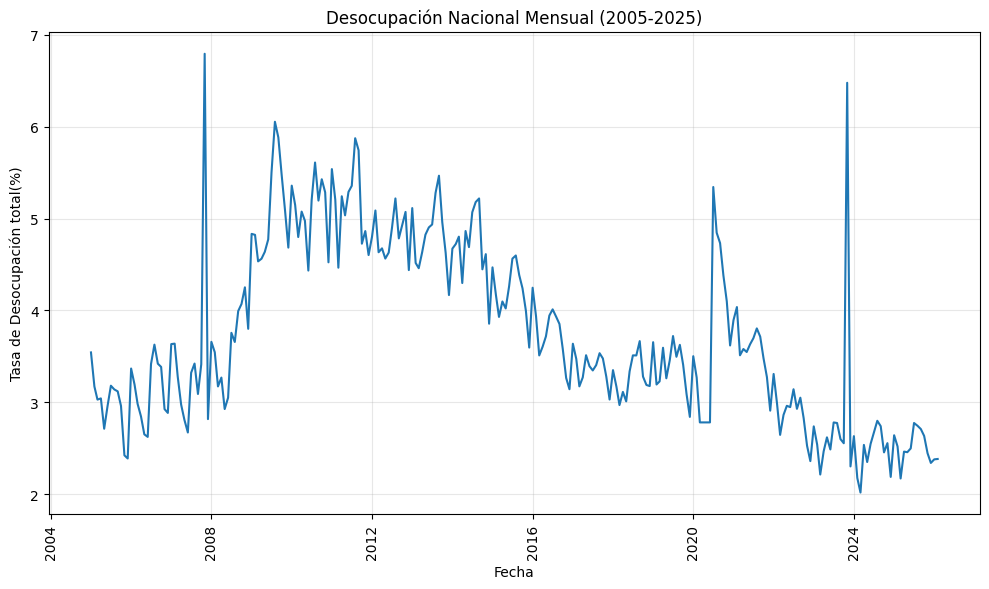

In [18]:
# Calcular promedio nacional mensual
desocupacion_nacional = df_des_cleaned_v01.groupby("YEAR_MONTH")["DESOCUPACION"].mean().reset_index()

# Ahora convertimos a datetime la columna "YEAR_MONTH" y la agregamos al df desocupacion_nacional bajo la
# columna "FECHA"
desocupacion_nacional["FECHA"] = pd.to_datetime(desocupacion_nacional["YEAR_MONTH"].str.replace("_", "-") + "-01")

# Ordenamos por fecha y reseteamos el index
desocupacion_nacional = desocupacion_nacional.sort_values("FECHA").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(desocupacion_nacional["FECHA"], desocupacion_nacional["DESOCUPACION"])

locator = mdates.AutoDateLocator()    # Automatic tick matks placement based on the date range
formatter = mdates.ConciseDateFormatter(locator)    # formats the date labels concisely
ax.xaxis.set_major_locator(locator)    # Applies the locator object to the axis
ax.xaxis.set_major_formatter(formatter)    # Applies the formatter object to the axis

plt.title("Desocupación Nacional Mensual (2005-2025)")
plt.xlabel("Fecha")
plt.ylabel("Tasa de Desocupación total(%)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Analizando la grafica, se puede observar que el periodo de mayor alza y mayor descenso en la tasa de desocupacion mensual promedio a nivel nacional, fue en el año 2024. De cerca le sigue la crisis hipotecaria del 2008.

## Pregunta 3 - PENDIENTE

> Elige las 3 entidades con mayor proporción de educación superior y las 3 entidades con menor proporción de educación secundaria en el último dato registrado, y grafica en un mismo panel sus series mensuales de desocupación, diferenciando visualmente el top y el bottom. Explica qué entidad muestra mayor volatilidad visual y cuál parece más estable.


In [19]:
df_merged_q3 = df_merged.copy()

# Obtenemos el ultimo dato registrado de escolaridad

# Obtenemos los años para los cuales hay registros de escolaridad
df_merged_q3_v1 = df_merged_q3.copy()
df_merged_q3_v1 = df_merged_q3_v1.loc[df_merged_q3_v1["ENTIDAD"] == "AGUASCALIENTES", df_merged_q3_v1.columns]

year_list = []
for i, year in enumerate(df_merged_q3_v1["YEAR"]):
    if pd.isna(df_merged_q3_v1.iloc[i][7]):
        None
    else:
        year_list.append(year) 

# Reducimos el dataframe a solo las filas de el ultimo dato de escolaridad registrado (ano 2023)
df_merged_q3_v2 = df_merged_q3.copy()
df_merged_q3_v2 = df_merged_q3_v2.loc[df_merged_q3_v2["YEAR"] == max(year_list), df_merged_q3_v2.columns].reset_index(drop=True)

# Ahora calculamos las proporciones por escolaridad con respecto al total, por entidad y modificamos el df
for i, entry in enumerate(df_merged_q3_v2["TOTAL"]):
    row = df_merged_q3_v2.iloc[i][-7:]
    for j in range(len(row)-1):
        row.iloc[j] = row.iloc[j]/entry
    row.iloc[-1]=1
    first_part = df_merged_q3_v2.iloc[i][:5].tolist()  # ENTIDAD, YEAR, PIB, INDICE, DESOCUPACION
    df_merged_q3_v2.iloc[i] = first_part + row.tolist()

# Obtenemos las 3 entidades con mayor proporcion de eduacion superior, y las 3 con menor proporcion de educacion
# secundaria
index_greater_superior = df_merged_q3_v2["SUPERIOR"].nlargest(3).index
index_lower_secundaria = df_merged_q3_v2["SECUNDARIA"].nsmallest(3).index
 
entidades_greatear_superior = df_merged_q3_v2["ENTIDAD"].iloc[index_greater_superior].tolist()
entidades_lower_secundaria = df_merged_q3_v2["ENTIDAD"].iloc[index_lower_secundaria].tolist()

# Obtenemos un dataframe de las entidades con mayor proporcion de educacion superior

df_merged_q3_v3 = df_merged_q3_v2.copy()
df_merged_q3_v3 = df_merged_q3_v3.loc[df_merged_q3_v3["ENTIDAD"].isin(entidades_greatear_superior), df_merged_q3_v3.columns]

display(entidades_greatear_superior)
display(entidades_lower_secundaria)

display(df_merged_q3_v3)


C:\Users\ossia\AppData\Local\Temp\ipykernel_12068\1136951330.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if pd.isna(df_merged_q3_v1.iloc[i][7]):


['CIUDAD_DE_MEXICO', 'NUEVO_LEON', 'SINALOA']

['CIUDAD_DE_MEXICO', 'YUCATAN', 'CHIAPAS']

,ENTIDAD,YEAR,PIB_(PRECIOS_CORRIENTES),INDICE,DESOCUPACION,INICIAL,MEDIA_SUPERIOR,PREESCOLAR,PRIMARIA,SECUNDARIA,SUPERIOR,TOTAL
6,CIUDAD_DE_MEXICO,2023,NaN,106.0,NaN,0.006290,0.189085,0.091582,0.311620,0.170921,0.230502,1.0
18,NUEVO_LEON,2023,NaN,103.7,NaN,0.006290,0.127672,0.131757,0.389630,0.183885,0.160766,1.0
24,SINALOA,2023,NaN,89.6,2.378333,0.012097,0.163062,0.130053,0.361393,0.178303,0.155093,1.0


## Pregunta 4

> Compara la distribución del PIB histórico nacional vs la distribución del PIB histórico excluyendo a los 3 estados con mayor actividad industrial y a los 3 con menor actividad industrial

## Pregunta 5

> Compara el Boxplot de educación superior de los 10 estados con mayor PIB vs el de los 10 estados con menor PIB

## Pregunta_6

> Realiza un bubbleplot que muestre el crecimiento del último año del PIB, la cantidad de estudiantes con grado desde media superior y actividad industrial

## Pregunta_7

> Realiza un gráfico que te permita identificar los outliers en actividad industrial y con un print menciona cuales son

## Pregunta_8

> Realiza un gráfico que ilustre la evolución académica de los 5 estados con menor PIB